# Gutenberg Text Classification Using a Transformer Model

This notebook applies a Transformer encoder to paragraph classification using four Project Gutenberg books.

The learning progression is:

```text
raw paragraphs
→ train / validation / test split
→ tokenization
→ training vocabulary
→ integer sequences
→ token + position embeddings
→ Transformer encoder
→ baseline Transformer
→ hyperparameter variation
→ pretrained GloVe embeddings
→ model comparison
```


## Classification Task

We will download 4 books:

- *The Call of the Wild*, by Jack London
- *Dracula*, by Bram Stoker
- *The Adventures of Sherlock Holmes*, by Arthur Conan Doyle
- *Twenty Thousand Leagues under the Sea*, by Jules Verne

We will split the books into a collection of paragraphs and train a machine learning model to determine the book a paragraph was taken from.


## Import Libraries


In [21]:
import os
import zipfile
import bs4 as bs
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras
from keras import ops
from keras.layers import *
from keras.models import Model
from keras.callbacks import EarlyStopping


## Plot Training Results


In [22]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label='train')
  ax[0].plot(history.history['val_accuracy'],label='validation')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[0].grid(True)

  ax[1].plot(history.history['loss'],label='train')
  ax[1].plot(history.history['val_loss'],label='validation')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  ax[1].grid(True)
  plt.show()

def print_best_metrics(h):
  print('Highest training accuracy:',np.max(h['accuracy']))
  print('Highest validation accuracy:',np.max(h['val_accuracy']))
  print('Lowest training loss:',np.min(h['loss']))
  print('Lowest validation loss:',np.min(h['val_loss']))


## Download the Four Books


In [23]:
def get_paragraph_list(url,skip):
  paragraphs = []
  data = urllib.request.urlopen(url).read()
  soup = bs.BeautifulSoup(data,'lxml')

  for paragraph in soup.find_all('p'):
    par = paragraph.get_text()
    if par:
      if len(par)>=30:
        paragraphs.append(par)

  return paragraphs[skip:]

books = [215,345,1661,164]
url_list = [f'http://www.gutenberg.org/files/{i}/{i}-h/{i}-h.htm' for i in books]

paragraphs = []
targets = []
skip = [1,5,1,0]

for u,url in enumerate(url_list):
  par = get_paragraph_list(url,skip[u])
  paragraphs = paragraphs+par
  targets = targets+[u for i in par]

  print('\nBook {} contains {} paragraphs'.format(u,len(par)))
  lengths = np.array([len(wl) for wl in par])
  print('Paragraph length stats:')
  print('min = {} max = {} mean = {:4f}'.format(np.min(lengths),np.max(lengths),np.mean(lengths)))
  print('First paragraph:')
  print(par[0])

targets = np.array(targets)



Book 0 contains 327 paragraphs
Paragraph length stats:
min = 43 max = 1558 mean = 534.504587
First paragraph:

Buck did not read the newspapers, or he would have known that trouble was
brewing, not alone for himself, but for every tide-water dog, strong of muscle
and with warm, long hair, from Puget Sound to San Diego. Because men, groping
in the Arctic darkness, had found a yellow metal, and because steamship and
transportation companies were booming the find, thousands of men were rushing
into the Northland. These men wanted dogs, and the dogs they wanted were heavy
dogs, with strong muscles by which to toil, and furry coats to protect them
from the frost.


Book 1 contains 1744 paragraphs
Paragraph length stats:
min = 30 max = 4713 mean = 473.360665
First paragraph:
We left in pretty good time, and came after nightfall to Klausenburgh.
Here I stopped for the night at the Hotel Royale. I had for dinner, or
rather supper, a chicken done up some way with red pepper, which was
very goo

In [24]:
len(paragraphs)

6294

In [25]:
p = np.random.randint(0,len(paragraphs))
print(paragraphs[p])


“A likely story! As if a man bent on felony would slam his door so as to
wake a household. What did they say, then, of the disappearance of these
gems?”



## Integer Sequence Representation

Now let's extract the integer sequences to describe the data.

The vocabulary must be extracted from the training text only, since the held-out validation and test text should not be used to build the model representation.

Since all sequences must have the same length, we choose a length and pad with zeros the shorter sequences and truncate the longer ones.

A vocabulary-size cutoff can also be used so that only the most common words are included in the numerical representation. Words outside that cutoff are assigned to token `0` and considered unknown. In this notebook, the complete training vocabulary is retained.


## Split the Raw Text into Training, Validation, and Test Sets


In [26]:
x_train_text,x_test_text,y_train,y_test = train_test_split(paragraphs,targets,test_size=0.2,random_state=42,stratify=targets)
x_train_text,x_val_text,y_train,y_val = train_test_split(x_train_text,y_train,test_size=0.2,random_state=42,stratify=y_train)

print('Training paragraphs:',len(x_train_text))
print('Validation paragraphs:',len(x_val_text))
print('Test paragraphs:',len(x_test_text))


Training paragraphs: 4028
Validation paragraphs: 1007
Test paragraphs: 1259


## Inspect a Random Training Example and Its Sequence Representation


In [27]:
p = np.random.randint(0,len(x_train_text))
print(x_train_text[p])



“So much the worse for him,” said Conseil.



## Tokenize the Paragraphs


In [28]:
from nltk.tokenize import wordpunct_tokenize

p_tok_train = [wordpunct_tokenize(p) for p in x_train_text]
p_tok_val = [wordpunct_tokenize(p) for p in x_val_text]
p_tok_test = [wordpunct_tokenize(p) for p in x_test_text]

print(p_tok_train[0])


['“', 'It', 'is', 'the', 'forest', 'of', 'the', 'Island', 'of', 'Crespo', ',”', 'thought', 'I', ';—', 'and', 'I', 'was', 'not', 'mistaken', '.']


## Build the Training Vocabulary

Words with indices greater than a chosen `max_words` cutoff would not be included in the training or test sequences and would usually be rare words.

Here, `max_words` is set to the complete training-vocabulary size, so all words observed in the training vocabulary are retained. Words not found in the training vocabulary are mapped to token `0`.


In [29]:
count = {}

for p in p_tok_train:
  for w in p:
    w = w.lower()
    count[w] = count.get(w,0)+1

vocabulary = list(count.keys())
frequencies = list(count.values())
vocabulary = ['UNKNOWN']+[vocabulary[i] for i in np.argsort(frequencies)][::-1]

index = {}
for i,w in enumerate(vocabulary):
  index[w] = i

max_words = len(vocabulary)
vocab_size = len(vocabulary)
maxlen = 128

print('Vocabulary size:',vocab_size)
print(vocabulary[:20])
print(vocabulary[-20:])


Vocabulary size: 14470
['UNKNOWN', ',', 'the', '.', 'and', 'of', 'to', 'i', 'a', 'in', 'it', 'that', 'he', 'was', '“', 'his', 'you', 'with', 'as', 'is']
['haze', 'interposed', 'gingerly', 'walled', 'controlling', 'subduing', 'restraining', 'inciting', 'loosened', 'lull', 'retains', 'atom', 'pedestal', 'talkin', 'tags', 'buckles', 'inscrutable', 'looted', 'wherefore', 'sledded']


## Inspect Selected Vocabulary Indices


In [30]:
for word in ['vampire','dracula','buck','dog','holmes','watson','nemo','submarine']:
  print(f'{word:10s}: {index.get(word,0)}')


vampire   : 1579
dracula   : 1401
buck      : 155
dog       : 352
holmes    : 133
watson    : 543
nemo      : 149
submarine : 620


## Convert Paragraphs to Fixed-Length Integer Sequences


In [31]:
def make_sequences(tokenized_paragraphs,index,maxlen=128):
  seq_arr = np.zeros((len(tokenized_paragraphs),maxlen),dtype=int)

  for i,p in enumerate(tokenized_paragraphs):
    ind_seq = []

    for w in p[:maxlen]:
      ind_seq.append(index.get(w.lower(),0))

    if len(ind_seq)>0:
      seq_arr[i,-len(ind_seq):] = ind_seq

  return seq_arr

x_train = make_sequences(p_tok_train,index,maxlen)
x_val = make_sequences(p_tok_val,index,maxlen)
x_test = make_sequences(p_tok_test,index,maxlen)

print('Training:',x_train.shape,y_train.shape)
print('Validation:',x_val.shape,y_val.shape)
print('Test:',x_test.shape,y_test.shape)


Training: (4028, 128) (4028,)
Validation: (1007, 128) (1007,)
Test: (1259, 128) (1259,)


## Inspect a Random Training Sequence


In [32]:
r = np.random.randint(len(x_train))
print(x_train[r])


[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0   14   59  328
   10  236    1   62  308   75   66  414    1 2111   22  190   60   25
  148   70]


## Decode the Sequence Back to Words


In [33]:
for i in x_train[r]:
  if i>0:
    print(vocabulary[i],end=' ')


“ what does it matter , some hours more or less , provided we get out at last ?” 

## Embedding Layer
Words with indices greater than max_words appear in word_index, but are not included in the training or test sequences. These are usually rare words.

We will create an embedding layer. An embedding layer receives parameters describing the vocabulary size, embedding length, and sequence length.

- `max_words` or `vocab_size` is the number of retained vocabulary indices.
- `emb_len` or `embed_dim` is the chosen number of dimensions used to represent each word embedding.
- `seq_len` or `maxlen` is the number of words in each paragraph after padding or truncation.

The parameters, or weights, of an embedding layer consist of a 2D array in which each row contains the embedding vector associated with one vocabulary index.

Because index `0` is already included in `vocab_size` in this implementation, the Keras embedding matrix contains `vocab_size` rows and `embed_dim` columns.


# Transformer Building Blocks

The model combines token and position embeddings with a Transformer block containing multi-head self-attention, a feed-forward network, residual connections, layer normalization, and dropout.


## Transformer Encoder Block


In [34]:
class TransformerBlock(Layer):
  def __init__(self,embed_dim,num_heads,ff_dim,rate=0.2):
    super().__init__()
    self.att = MultiHeadAttention(num_heads=num_heads,key_dim=embed_dim)
    self.ffn = keras.Sequential([Dense(ff_dim,activation='relu'),Dense(embed_dim)])
    self.layernorm1 = LayerNormalization(epsilon=1e-6)
    self.layernorm2 = LayerNormalization(epsilon=1e-6)
    self.dropout1 = Dropout(rate)
    self.dropout2 = Dropout(rate)

  def call(self,inputs):
    attn_output = self.att(inputs,inputs)
    attn_output = self.dropout1(attn_output)
    out1 = self.layernorm1(inputs+attn_output)
    ffn_output = self.ffn(out1)
    ffn_output = self.dropout2(ffn_output)
    return self.layernorm2(out1+ffn_output)


## Token and Position Embedding


In [35]:
class TokenAndPositionEmbedding(Layer):
  def __init__(self,maxlen,vocab_size,embed_dim):
    super().__init__()
    self.token_emb = Embedding(input_dim=vocab_size,output_dim=embed_dim)
    self.pos_emb = Embedding(input_dim=maxlen,output_dim=embed_dim)

  def call(self,x):
    maxlen = ops.shape(x)[-1]
    positions = ops.arange(start=0,stop=maxlen,step=1)
    positions = self.pos_emb(positions)
    x = self.token_emb(x)
    return x+positions


# 1. Baseline Transformer

The baseline model uses the same hyperparameter definitions as the supplied Transformer implementation.


In [36]:
embed_dim = 32  # Embedding size for each token
num_heads = 2  # Number of attention heads
ff_dim = 32  # Hidden layer size in feed forward network inside transformer
maxlen = 128

inputs = Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen,vocab_size,embed_dim)
x = embedding_layer(inputs)
transformer_block = TransformerBlock(embed_dim,num_heads,ff_dim)
x = transformer_block(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)
x = Dense(20,activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(4,activation='softmax')(x)

model = Model(inputs=inputs,outputs=outputs)
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_3  │ (None, 128, 32)        │       467,136 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 128, 32)        │        10,656 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 478,536 (1.83 MB)

 Trainable params: 478,536 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

## Train and Evaluate the Baseline Transformer


Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.3893 - loss: 1.2007 - val_accuracy: 0.4687 - val_loss: 1.0910
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.5993 - loss: 0.8866 - val_accuracy: 0.8203 - val_loss: 0.4913
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.8776 - loss: 0.3564 - val_accuracy: 0.9057 - val_loss: 0.2641
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9541 - loss: 0.1646 - val_accuracy: 0.8987 - val_loss: 0.3275
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.9799 - loss: 0.0771 - val_accuracy: 0.9027 - val_loss: 0.3737
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.9881 - loss: 0.0467 - val_accuracy: 0.9067 - val_loss: 0.3564
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9950 - loss: 0.0248 - val_accuracy: 0.9086 - val_loss: 0.4131
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.9940 - loss: 0.0202 - 

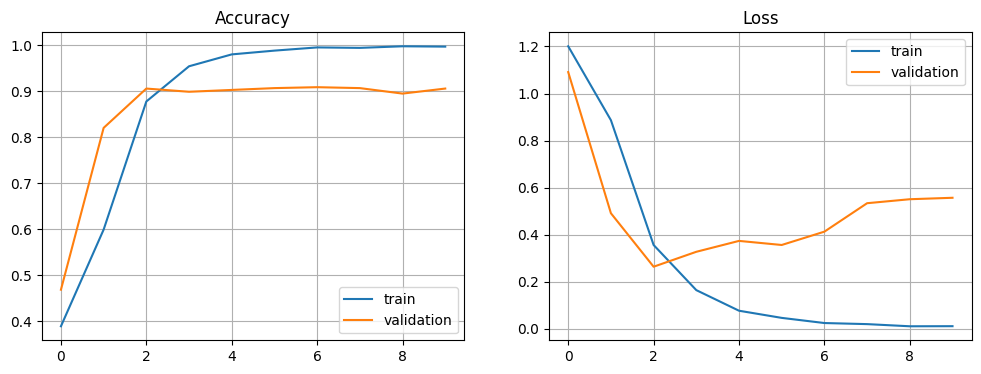

Highest training accuracy: 0.9975174069404602
Highest validation accuracy: 0.9086395502090454
Lowest training loss: 0.01100433524698019
Lowest validation loss: 0.2640683948993683
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Test confusion matrix:
[[ 61   2   2   0]
 [  1 315  25   8]
 [  4  11 398  13]
 [  5   5  24 385]]
Test accuracy: 0.920571882446386


In [37]:
earlystopping = EarlyStopping(monitor='val_accuracy',patience=3,restore_best_weights=True)

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history = model.fit(x_train,y_train,batch_size=32,epochs=10,validation_data=(x_val,y_val),callbacks=[earlystopping])

plot_results(history)
print_best_metrics(history.history)

pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
baseline_accuracy = accuracy_score(y_test,pred_class)

print('Test confusion matrix:')
print(confusion_matrix(y_test,pred_class))
print('Test accuracy:',baseline_accuracy)


# 2. Model Improvement Experiments

The next experiments try to improve the Transformer classification performance by:

- modifying the model's hyperparameters,
- using pretrained embeddings.

The first experiment defines new hyperparameters, rebuilds the model architecture with those values, and then instantiates and trains the new model.


## Hyperparameter Variation


In [38]:
embed_dim = 64
num_heads = 4
ff_dim = 64
dropout_rate = 0.3

embedding_layer_new = TokenAndPositionEmbedding(maxlen,vocab_size,embed_dim)
transformer_block_new = TransformerBlock(embed_dim,num_heads,ff_dim,dropout_rate)

inputs_new = Input(shape=(maxlen,))
x = embedding_layer_new(inputs_new)
x = transformer_block_new(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(dropout_rate)(x)
x = Dense(20,activation='relu')(x)
x = Dropout(dropout_rate)(x)
outputs_new = Dense(4,activation='softmax')(x)

model_new = Model(inputs=inputs_new,outputs=outputs_new)
model_new.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_4  │ (None, 128, 64)        │       934,272 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 128, 64)        │        74,944 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 20)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,010,600 (3.86 MB)

 Trainable params: 1,010,600 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

The supplied solution used `dropout_rate_new` in this architecture even though only `dropout_rate` was defined. The portfolio implementation uses the defined `dropout_rate` consistently.


## Train and Evaluate the Hyperparameter-Variation Model


Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - accuracy: 0.3744 - loss: 1.2419 - val_accuracy: 0.4717 - val_loss: 1.0949
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 38s 301ms/step - accuracy: 0.6388 - loss: 0.8535 - val_accuracy: 0.8540 - val_loss: 0.3920
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 32s 253ms/step - accuracy: 0.9002 - loss: 0.3174 - val_accuracy: 0.9096 - val_loss: 0.2430
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 33s 264ms/step - accuracy: 0.9600 - loss: 0.1481 - val_accuracy: 0.9076 - val_loss: 0.3170
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 33s 261ms/step - accuracy: 0.9804 - loss: 0.0757 - val_accuracy: 0.9017 - val_loss: 0.3814
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 40s 255ms/step - accuracy: 0.9903 - loss: 0.0439 - val_accuracy: 0.9037 - val_loss: 0.4411


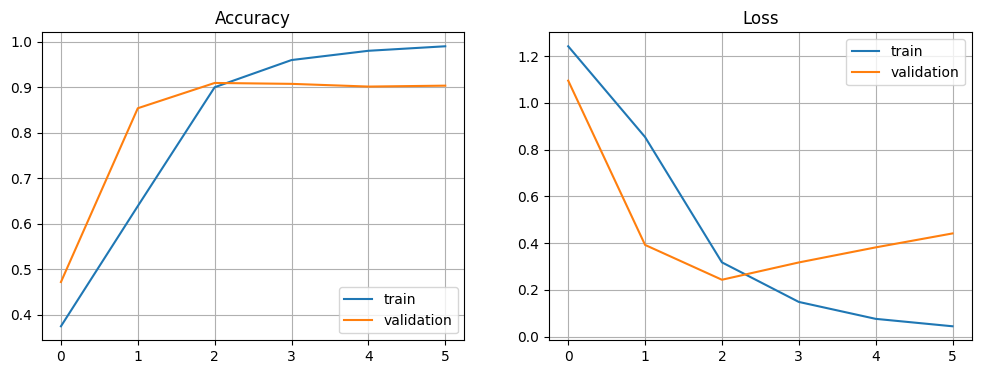

Highest training accuracy: 0.9903177618980408
Highest validation accuracy: 0.9096325635910034
Lowest training loss: 0.04387938603758812
Lowest validation loss: 0.24296367168426514
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step
Test confusion matrix:
[[ 55   2   5   3]
 [  1 297  41  10]
 [  0   8 408  10]
 [  0   7  26 386]]
Test accuracy: 0.9102462271644162


In [39]:
model_new.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history_new = model_new.fit(x_train,y_train,batch_size=32,epochs=10,validation_data=(x_val,y_val),callbacks=[earlystopping])

plot_results(history_new)
print_best_metrics(history_new.history)

pred = model_new.predict(x_test)
pred_class = np.argmax(pred,axis=1)
tuned_accuracy = accuracy_score(y_test,pred_class)

print('Test confusion matrix:')
print(confusion_matrix(y_test,pred_class))
print('Test accuracy:',tuned_accuracy)


# 3. Use Pretrained Embeddings

Integrate pretrained GloVe word embeddings into the Transformer model. This involves downloading the embeddings, creating an embedding matrix for the vocabulary, and then initializing the model's embedding layer with these weights.

This portfolio uses the `glove.6B.100d.txt` file.


## Download GloVe 6B


In [40]:
glove_dir = '/tmp/glv/'

if not os.path.exists(glove_dir):
  os.makedirs(glove_dir)

glove_zip_path = os.path.join(glove_dir,'glove.6B.zip')

if not os.path.exists(glove_zip_path):
  print('Downloading GloVe embeddings...')
  urllib.request.urlretrieve('http://nlp.stanford.edu/data/glove.6B.zip',glove_zip_path)

glove_txt_path = os.path.join(glove_dir,'glove.6B.100d.txt')

if not os.path.exists(glove_txt_path):
  print('Unzipping GloVe embeddings...')
  with zipfile.ZipFile(glove_zip_path,'r') as zip_ref:
    zip_ref.extractall(glove_dir)

print('GloVe embeddings ready in:',glove_dir)


Unzipping GloVe embeddings...
GloVe embeddings ready in: /tmp/glv/


## Read the 100-Dimensional GloVe Vectors


In [41]:
embeddings_index = {}
embedding_dim = 100

with open(glove_txt_path,encoding='utf-8') as f:
  for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:],dtype='float32')
    embeddings_index[word] = coefs

print('Found',len(embeddings_index),'word vectors.')


Found 400000 word vectors.


With the GloVe embeddings loaded, construct an embedding matrix for our model's vocabulary, initializing it with the pretrained GloVe vectors or random vectors for unknown words.

## Construct the Pretrained Embedding Matrix

With the GloVe embeddings loaded, construct an embedding matrix for the model's vocabulary, initializing known words with their pretrained GloVe vectors.

For words not found in GloVe, the embedding row is initialized with a small random vector. Index `0` is kept at zero for the padding/unknown position.


In [42]:
embedding_matrix = np.zeros((vocab_size,embedding_dim))
words_found = 0

for i,word in enumerate(vocabulary):
  if i == 0:
    continue

  embedding_vector = embeddings_index.get(word)

  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector
    words_found += 1
  else:
    embedding_matrix[i] = np.random.normal(scale=0.05,size=(embedding_dim,))

print('Shape of embedding matrix:',embedding_matrix.shape)
print('Vocabulary words found in GloVe:',words_found)


Shape of embedding matrix: (14470, 100)
Vocabulary words found in GloVe: 13723


## Build a Transformer with Frozen Pretrained Embeddings

Now that the embedding matrix is prepared, the next step is to build a new Transformer model.

The model initializes the token `Embedding` layer with the pretrained `embedding_matrix` and sets `trainable=False` to keep these token-embedding weights fixed during training.

The rest of the architecture remains similar to the previous models. The embedding dimension is adjusted to match the 100-dimensional GloVe vectors. Position embeddings remain trainable.


In [43]:
class PretrainedTokenAndPositionEmbedding(Layer):
  def __init__(self,maxlen,vocab_size,embed_dim,embedding_matrix):
    super().__init__()
    self.token_emb = Embedding(input_dim=vocab_size,output_dim=embed_dim,weights=[embedding_matrix],trainable=False)
    self.pos_emb = Embedding(input_dim=maxlen,output_dim=embed_dim)

  def call(self,x):
    maxlen = ops.shape(x)[-1]
    positions = ops.arange(start=0,stop=maxlen,step=1)
    positions = self.pos_emb(positions)
    x = self.token_emb(x)
    return x+positions


## Build the GloVe Transformer


In [44]:
embed_dim_glove = embedding_dim
num_heads_glove = 4
ff_dim_glove = 64
dropout_rate_glove = 0.3

inputs_glove = Input(shape=(maxlen,))
embedding_layer_glove = PretrainedTokenAndPositionEmbedding(maxlen,vocab_size,embed_dim_glove,embedding_matrix)

x = embedding_layer_glove(inputs_glove)
transformer_block_glove = TransformerBlock(embed_dim_glove,num_heads_glove,ff_dim_glove,dropout_rate_glove)
x = transformer_block_glove(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(dropout_rate_glove)(x)
x = Dense(20,activation='relu')(x)
x = Dropout(dropout_rate_glove)(x)
outputs_glove = Dense(4,activation='softmax')(x)

model_glove = Model(inputs=inputs_glove,outputs=outputs_glove)
model_glove.summary()


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pretrained_token_and_position_… │ (None, 128, 100)       │     1,459,800 │
│ (PretrainedTokenAndPositionEmb… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 128, 100)       │       174,664 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │            84 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,636,568 (6.24 MB)

 Trainable params: 189,568 (740.50 KB)

 Non-trainable params: 1,447,000 (5.52 MB)

## Train and Evaluate the GloVe Transformer


Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 58s 431ms/step - accuracy: 0.4528 - loss: 1.1564 - val_accuracy: 0.6495 - val_loss: 0.8122
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 62s 487ms/step - accuracy: 0.6686 - loss: 0.7669 - val_accuracy: 0.7468 - val_loss: 0.6467
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 53s 417ms/step - accuracy: 0.7483 - loss: 0.6107 - val_accuracy: 0.7587 - val_loss: 0.5554


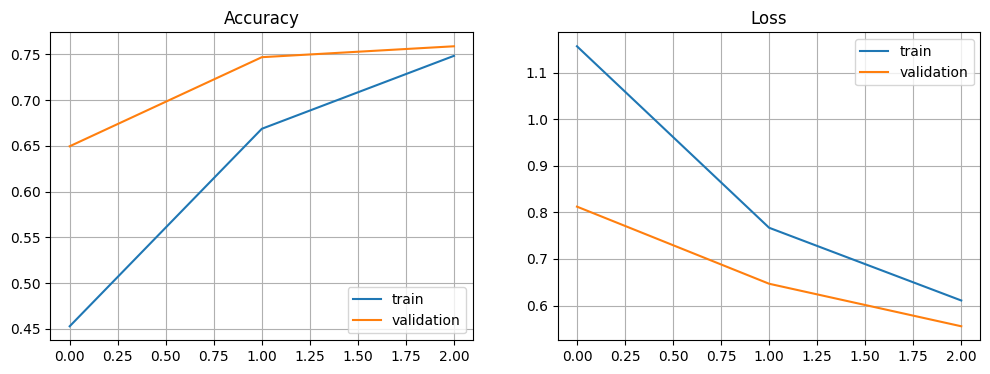

Highest training accuracy: 0.7482621669769287
Highest validation accuracy: 0.7586891651153564
Lowest training loss: 0.6107480525970459
Lowest validation loss: 0.5554112195968628
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step
Test confusion matrix:
[[  7  30  19   9]
 [  0 162 172  15]
 [  0  47 346  33]
 [  0   1 108 310]]
Test accuracy: 0.6552819698173153


In [45]:
model_glove.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history_glove = model_glove.fit(x_train,y_train,batch_size=32,epochs=10,validation_data=(x_val,y_val),callbacks=[earlystopping])

plot_results(history_glove)
print_best_metrics(history_glove.history)

pred = model_glove.predict(x_test)
pred_class = np.argmax(pred,axis=1)
glove_accuracy = accuracy_score(y_test,pred_class)

print('Test confusion matrix:')
print(confusion_matrix(y_test,pred_class))
print('Test accuracy:',glove_accuracy)


## Compare the Three Transformer Configurations


In [46]:
results = {
  'Baseline Transformer':baseline_accuracy,
  'Hyperparameter Variation':tuned_accuracy,
  'Frozen GloVe Transformer':glove_accuracy
}

for model_name,acc in sorted(results.items(),key=lambda x:x[1],reverse=True):
  print(f'{model_name:28s}: {acc:.4f}')


Baseline Transformer        : 0.9206
Hyperparameter Variation    : 0.9102
Frozen GloVe Transformer    : 0.6553


## Recorded Experimental Results

Across the three tested models, the recorded written summary reported that the Baseline Model delivered the strongest results:

**Best Validation Accuracy:** 0.9063  
**Best Validation Loss:** 0.2559

The Hyperparameter-Tuned Model (`embed_dim=64`, `num_heads=4`, `ff_dim=64`, `dropout=0.3`) performed slightly worse, reaching **0.9040 accuracy** and **0.2774 loss**. The changes did not provide meaningful improvement and may have increased model complexity without benefiting generalization.

The GloVe Pretrained Embeddings Model showed the lowest performance, with **0.8349 accuracy** and **0.4923 loss**. Likely reasons include domain mismatch, limited adaptability from using `trainable=False`, and the fact that this dataset allows the model to learn effective embeddings from scratch.

These values are retained as the recorded comparison. Because the corrected portfolio workflow uses separate training, validation, and test sets, the rerun **test accuracies** should be used for the final portfolio comparison.


## Key Takeaways

- A Transformer encoder can classify text sequences without recurrent hidden-state updates.
- Token embeddings and position embeddings are combined before self-attention.
- Increasing embedding dimension, attention heads, feed-forward width, and dropout does not guarantee improved generalization.
- Pretrained GloVe vectors provide an external initialization, but freezing them can limit task-specific adaptation.
- The training vocabulary should be built from training text only.
- Validation data should guide model selection, while the final test set should be reserved for final evaluation.
